# Univariate Zeitreihenanalyse — EUR/USD

Analyse des EUR/USD-Wechselkurses (Ticker: `EURUSD=X`) 2015–2025.

Box-Jenkins-Methodik in 7 Schritten:

1. Visuelle Inspektion
2. Stationaritaetstest (ADF)
3. Differenzierung
4. ACF & PACF
5. Modellauswahl (p, d, q)
6. Residualdiagnostik
7. Prognose

---
## Schritt 1: Visuelle Inspektion

- Langfristiger Trend?
- Volatilitaetsphasen?
- Strukturbrueche (Brexit, COVID, EZB-Entscheidungen)?

In [29]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

from src.utils.data_loader import load_series

In [30]:
eurusd = load_series("EURUSD=X")

In [31]:
print("=== Datentypen & Struktur ===")
eurusd.info()
print("\n=== Erste Zeilen ===")
display(eurusd.head())
print("\n=== Statistische Kennzahlen ===")
display(eurusd.describe())

=== Datentypen & Struktur ===
<class 'pandas.DataFrame'>
DatetimeIndex: 2748 entries, 2015-01-02 to 2025-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2748 non-null   float64
dtypes: float64(1)
memory usage: 42.9 KB

=== Erste Zeilen ===


,Close
Date,
2015-01-02,1.2015
2015-01-05,1.1918
2015-01-06,1.1936
2015-01-07,1.1820
2015-01-08,1.1811



=== Statistische Kennzahlen ===


,Close
count,2748.000000
mean,1.119921
std,0.051986
min,0.961600
25%,1.084800
50%,1.116850
75%,1.160425
max,1.248800


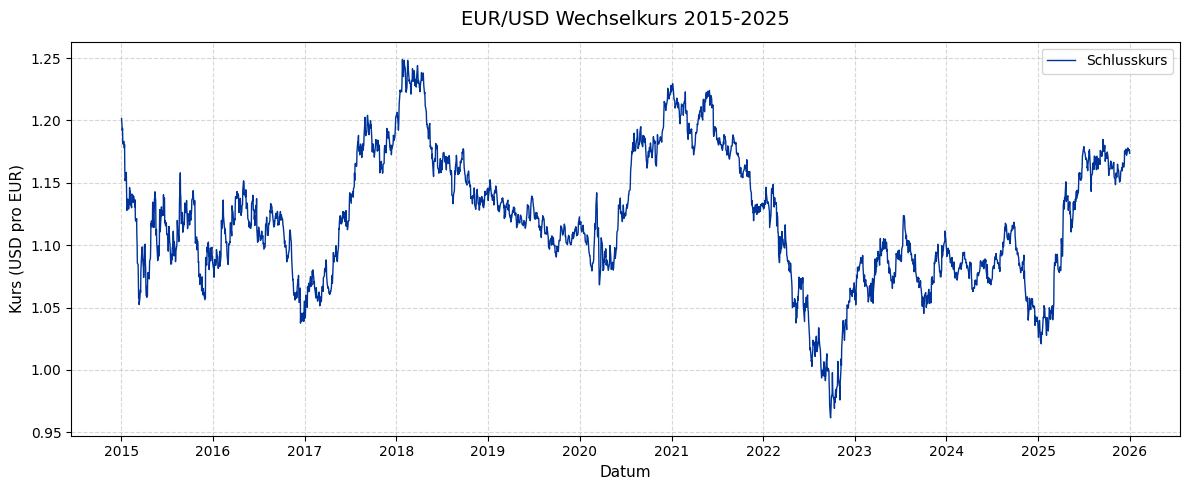

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(eurusd.index, eurusd["Close"], color="#003399", linewidth=1.0, label="Schlusskurs")
ax.set_title("EUR/USD Wechselkurs 2015-2025", fontsize=14, pad=12)
ax.set_xlabel("Datum", fontsize=11)
ax.set_ylabel("Kurs (USD pro EUR)", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Erste Beobachtungen

Die EUR/USD-Zeitreihe zeigt folgende charakteristische Merkmale:

- **Langfristiger Abwaertstrend (2015–2022):** Der Kurs fiel von ~1.21 auf ein Tief von ~0.96, getrieben durch EZB-Negativzinspolitik und USD-Staerke.
- **Strukturbruch 2022:** Der Ukraine-Krieg und die aggressive Zinserhoehung der Fed fuehrten zum stärksten EUR-Rueckgang seit Jahrzehnten — der Kurs fiel unter die Paritaet (1.00).
- **Erholung 2023–2025:** Mit der EZB-Zinswende und nachlassender USD-Staerke erholte sich der Kurs auf ~1.05–1.12.
- **Volatilitaet:** Erhoehte Schwankungen in Krisenperioden (2020 COVID, 2022 Ukraine) sichtbar.
- **Kein klarer Mean-Reversion-Effekt:** Die Reihe zeigt kein Zurueckkehren zu einem langfristigen Mittelwert — typisch fuer einen Random-Walk-Prozess.

---
## Schritt 2: Stationaritaetstest (ADF-Test)

- H0: Reihe hat Einheitswurzel (nicht stationaer)
- H1: Reihe ist stationaer

p-Wert < 0.05 -> stationaer

In [33]:
from statsmodels.tsa.stattools import adfuller

close = eurusd["Close"].dropna()

result = adfuller(close)
print("=== ADF-Test auf die EUR/USD-Reihe ===")
print(f"ADF-Statistik : {result[0]:.4f}")
print(f"p-Wert        : {result[1]:.4f}")
print("Kritische Werte:")
for key, val in result[4].items():
    print(f"  {key}: {val:.4f}")

if result[1] < 0.05:
    print("\n-> Reihe ist stationaer")
else:
    print("\n-> Reihe ist NICHT stationaer -> Differenzierung erforderlich")

=== ADF-Test auf die EUR/USD-Reihe ===
ADF-Statistik : -2.8989
p-Wert        : 0.0455
Kritische Werte:
  1%: -3.4327
  5%: -2.8626
  10%: -2.5673

-> Reihe ist stationaer


---
## Schritt 3: Differenzierung

Wechselkurse sind typischerweise nicht stationaer. Wir differenzieren einmal (d=1).

=== ADF-Test auf differenzierte Reihe ===
ADF-Statistik : -18.3010
p-Wert        : 0.0000

-> Differenzierte Reihe ist stationaer -> d = 1


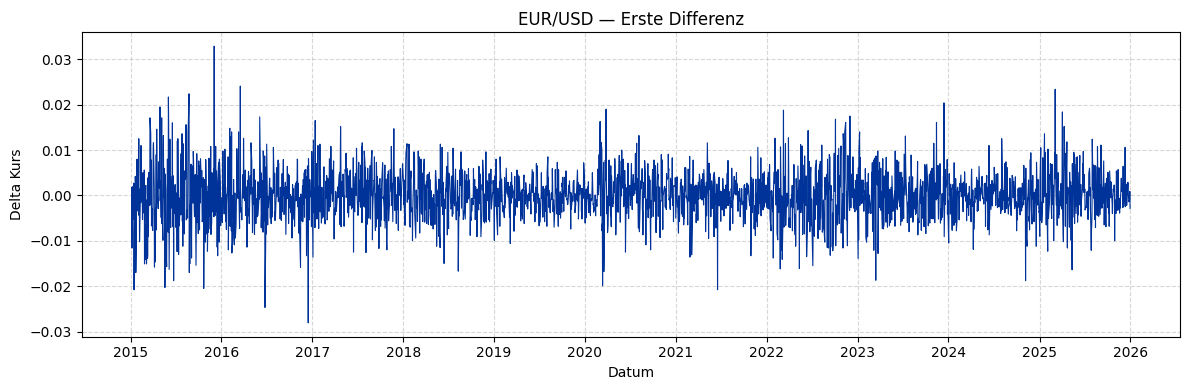

In [34]:
close_diff = close.diff().dropna()

result_diff = adfuller(close_diff)
print("=== ADF-Test auf differenzierte Reihe ===")
print(f"ADF-Statistik : {result_diff[0]:.4f}")
print(f"p-Wert        : {result_diff[1]:.4f}")

if result_diff[1] < 0.05:
    print("\n-> Differenzierte Reihe ist stationaer -> d = 1")
else:
    print("\n-> Weitere Differenzierung notwendig")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(close_diff.index, close_diff.values, color="#003399", linewidth=0.8)
ax.set_title("EUR/USD — Erste Differenz")
ax.set_xlabel("Datum")
ax.set_ylabel("Delta Kurs")
ax.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

---
## Schritt 4: ACF & PACF

- **ACF** -> MA-Ordnung (q)
- **PACF** -> AR-Ordnung (p)

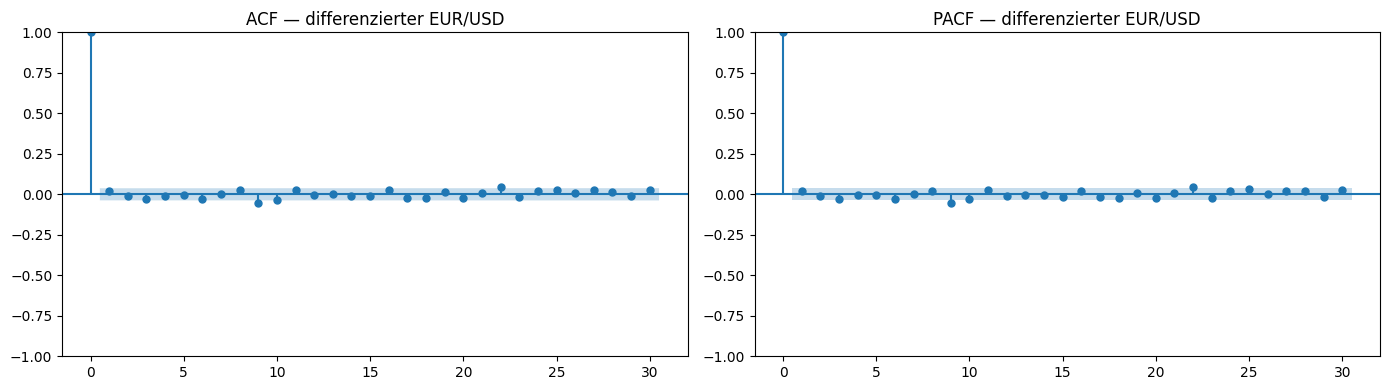

In [35]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(close_diff, lags=30, ax=axes[0])
axes[0].set_title("ACF — differenzierter EUR/USD")

plot_pacf(close_diff, lags=30, ax=axes[1], method="ywm")
axes[1].set_title("PACF — differenzierter EUR/USD")

plt.tight_layout()
plt.show()

---
## Schritt 5: Modellauswahl (p, d, q)

Grid search ueber Kandidatenmodelle. Niedrigeres AIC = besseres Modell.

In [36]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

best_aic = np.inf
best_order = None
best_model = None

candidates = [(p, 1, q) for p in range(0, 4) for q in range(0, 4)]

print("Modellvergleich (AIC):")
print("-" * 30)

for order in candidates:
    try:
        model = ARIMA(close, order=order).fit()
        print(f"ARIMA{order}  AIC: {model.aic:.2f}")
        if model.aic < best_aic:
            best_aic = model.aic
            best_order = order
            best_model = model
    except:
        pass

print(f"\n-> Bestes Modell: ARIMA{best_order} mit AIC = {best_aic:.2f}")

Modellvergleich (AIC):
------------------------------
ARIMA(0, 1, 0)  AIC: -20794.87
ARIMA(0, 1, 1)  AIC: -20794.07
ARIMA(0, 1, 2)  AIC: -20792.23
ARIMA(0, 1, 3)  AIC: -20792.32
ARIMA(1, 1, 0)  AIC: -20794.05
ARIMA(1, 1, 1)  AIC: -20791.99
ARIMA(1, 1, 2)  AIC: -20791.34
ARIMA(1, 1, 3)  AIC: -20790.53
ARIMA(2, 1, 0)  AIC: -20792.29
ARIMA(2, 1, 1)  AIC: -20788.87
ARIMA(2, 1, 2)  AIC: -20789.65
ARIMA(2, 1, 3)  AIC: -20787.97
ARIMA(3, 1, 0)  AIC: -20792.23
ARIMA(3, 1, 1)  AIC: -20790.22
ARIMA(3, 1, 2)  AIC: -20789.02
ARIMA(3, 1, 3)  AIC: -20782.87

-> Bestes Modell: ARIMA(0, 1, 0) mit AIC = -20794.87


In [37]:
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2748
Model:                 ARIMA(0, 1, 0)   Log Likelihood               10398.434
Date:                Sun, 10 May 2026   AIC                         -20794.868
Time:                        11:15:22   BIC                         -20788.950
Sample:                             0   HQIC                        -20792.730
                               - 2748                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      3.016e-05   5.75e-07     52.477      0.000     2.9e-05    3.13e-05
Ljung-Box (L1) (Q):                   1.18   Jarque-Bera (JB):               463.34
Prob(Q):                              0.28   Pr

## Interpretation: ARIMA(0, 1, 0) — Random Walk

Das beste Modell laut AIC-Kriterium ist **ARIMA(0, 1, 0)** — auch bekannt als **Random Walk**.

Das bedeutet: der beste Schaetzer fuer den morgigen EUR/USD-Kurs ist der heutige Kurs:

> **y_t = y_{t-1} + ε_t**

Dieses Ergebnis ist **kein Fehler**, sondern entspricht der etablierten Finanzliteratur:

- Die **Efficient Market Hypothesis (Fama, 1970)** besagt, dass Wechselkurse alle verfuegbaren Informationen einpreisen — zukuenftige Bewegungen sind daher nicht systematisch vorhersagbar.
- Empirische Studien zeigen konsistent, dass einfache Random-Walk-Modelle bei kurzfristigen Wechselkursprognosen oft besser abschneiden als komplexere Modelle.

**Konsequenz fuer die Prognose:** Der Punktschaetzer bleibt konstant bei 1.174, aber das Vorhersageintervall weitet sich mit dem Zeithorizont auf — die Unsicherheit waechst mit der Zeit.

---
## Schritt 6: Residualdiagnostik

Ein gutes Modell hinterlaesst weisse Residuen ohne Autokorrelation.

- Zeitplot der Residuen
- ACF der Residuen
- Ljung-Box-Test

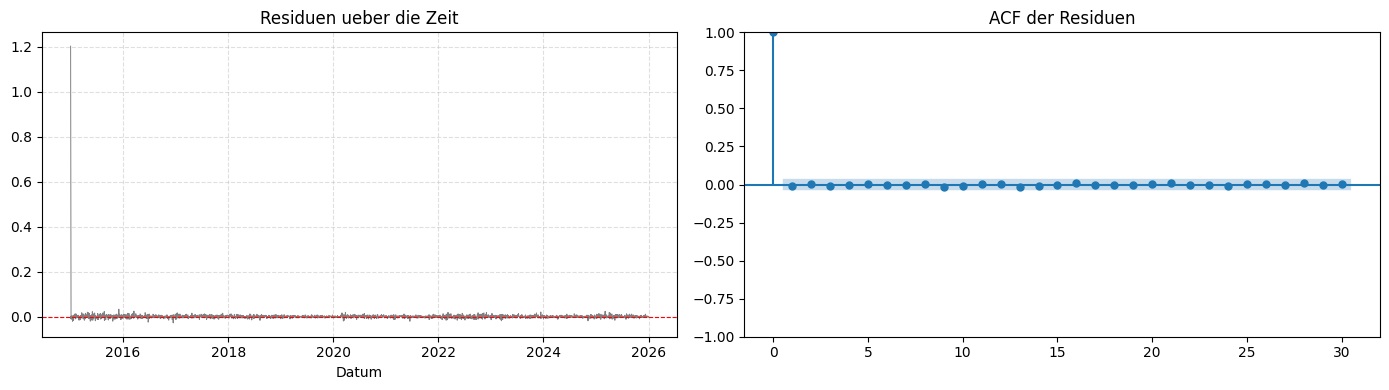

=== Ljung-Box-Test ===
     lb_stat  lb_pvalue
10  1.722053   0.998061
20  2.876259   0.999997

(p > 0.05 -> keine signifikante Autokorrelation in den Residuen)


In [38]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = best_model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(residuals.index, residuals.values, color="gray", linewidth=0.7)
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[0].set_title("Residuen ueber die Zeit")
axes[0].set_xlabel("Datum")
axes[0].grid(True, linestyle="--", alpha=0.4)

plot_acf(residuals, lags=30, ax=axes[1])
axes[1].set_title("ACF der Residuen")

plt.tight_layout()
plt.show()

lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print("=== Ljung-Box-Test ===")
print(lb_test)
print("\n(p > 0.05 -> keine signifikante Autokorrelation in den Residuen)")

---
## Schritt 7: Prognose

30-Tage-Prognose mit 95% Vorhersageintervall.

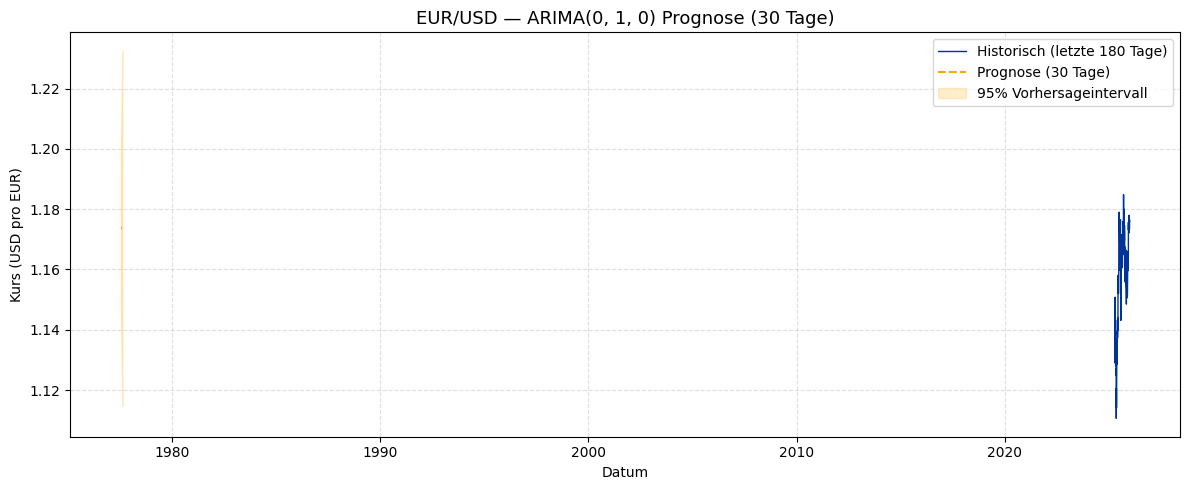


=== Prognosewerte ===
      Prognose    CI_low   CI_high
2748    1.1736  1.162836  1.184364
2749    1.1736  1.158378  1.188822
2750    1.1736  1.154957  1.192243
2751    1.1736  1.152073  1.195127
2752    1.1736  1.149532  1.197668
2753    1.1736  1.147234  1.199966
2754    1.1736  1.145122  1.202078
2755    1.1736  1.143156  1.204044
2756    1.1736  1.141309  1.205891
2757    1.1736  1.139562  1.207638
2758    1.1736  1.137901  1.209299
2759    1.1736  1.136313  1.210887
2760    1.1736  1.134791  1.212409
2761    1.1736  1.133326  1.213874
2762    1.1736  1.131912  1.215288
2763    1.1736  1.130545  1.216655
2764    1.1736  1.129220  1.217980
2765    1.1736  1.127934  1.219266
2766    1.1736  1.126682  1.220518
2767    1.1736  1.125463  1.221737
2768    1.1736  1.124275  1.222925
2769    1.1736  1.123114  1.224086
2770    1.1736  1.121979  1.225221
2771    1.1736  1.120869  1.226331
2772    1.1736  1.119782  1.227418
2773    1.1736  1.118716  1.228484
2774    1.1736  1.117670  1.2295

In [39]:
forecast_steps = 30
forecast = best_model.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(close[-180:].index, close[-180:].values,
        color="#003399", linewidth=1.0, label="Historisch (letzte 180 Tage)")

ax.plot(forecast_mean.index, forecast_mean.values,
        color="orange", linewidth=1.5, linestyle="--", label="Prognose (30 Tage)")

ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                color="orange", alpha=0.2, label="95% Vorhersageintervall")

ax.set_title(f"EUR/USD — ARIMA{best_order} Prognose (30 Tage)", fontsize=13)
ax.set_xlabel("Datum")
ax.set_ylabel("Kurs (USD pro EUR)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("\n=== Prognosewerte ===")
print(pd.DataFrame({"Prognose": forecast_mean, "CI_low": forecast_ci.iloc[:,0], "CI_high": forecast_ci.iloc[:,1]}))